In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat
import ast

In [2]:
!hostname

ampere02


In [3]:
# Data
conv = {c: ast.literal_eval for c in ['T_entrada', 'S_entrada', 'I_entrada', 'R_entrada', 'T_pronostico','I_pronostico','u_pronostico']}

data_train = pd.read_csv('simulaciones_SIR_V7_130k.csv', converters=conv)
data_test = pd.read_csv('simulaciones_SIR_V7_26k.csv', converters=conv)

## Análisis exploratorio

In [4]:
data_train.head(1)

,R_0,gamma,beta,S0,I0,Altura_pico,Tiempo_pico,T_entrada,S_entrada,I_entrada,R_entrada,T_pronostico,I_pronostico,u_pronostico,T_restante,I_restante,u_restante
0,1.111405,0.127382,0.141573,0.85194,0.14806,critica,pre_pico,"[24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31....","[0.5714272512818945, 0.5655768179652128, 0.560...","[0.07231796808678627, 0.06895638759564947, 0.0...","[0.3562547806313194, 0.365466794439138, 0.3742...","[38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45....","[0.03484677286388997, 0.032331752834281205, 0....","[0.2413631777825137, 0.2237300258566464, 0.206...","[52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59....","[0.013271013796927425, 0.012447345134790063, 0...","[0.06771297831069634, 0.060935634845912225, 0...."


In [5]:
# Analisis exploratorio de datos
def porcentaje(data):
    data_explor = pd.DataFrame(data['Altura_pico'].value_counts())
    data_explor.rename(columns = {'count':'Cantidad'}, inplace=True)
    data_explor_sum = data_explor['Cantidad'].sum()
    data_explor['Porcentaje'] = (data_explor / data_explor_sum) * 100
    return data_explor

data_train_explor = porcentaje(data_train)
data_test_explor = porcentaje(data_test)

table = pd.concat([data_train_explor, data_test_explor], axis=1)
table

,Cantidad,Porcentaje,Cantidad,Porcentaje
Altura_pico,,,,
critica,43593,33.533077,8706,33.484615
extrema,43230,33.253846,8706,33.484615
irreal,20247,15.574615,4100,15.769231
ola_severa,14758,11.352308,2876,11.061538
ola_en_marcha,4479,3.445385,928,3.569231
inicia_presion,3229,2.483846,606,2.330769
crecimiento_claro,358,0.275385,58,0.223077
brote_incipiente,106,0.081538,20,0.076923


# Construir los tensores X e Y

## Tensores de Red Neuronal 1 (Estimador de Estado)

In [6]:
# Construir el array en 3D
def build_tensors_EE(data):
    I_entrada = np.stack(data['I_entrada'].to_numpy()).astype('float32')
    S_salida = np.stack(data['S_entrada'].to_numpy()).astype('float32')
    R_salida = np.stack(data['R_entrada'].to_numpy()).astype('float32')
    
    return np.expand_dims((I_entrada), axis=2), np.stack((S_salida, R_salida), axis=2)

# Tensores de entrada y salida
X_train_EE, y_train_EE = build_tensors_EE(data_train)
X_test_EE, y_test_EE = build_tensors_EE(data_test)

In [7]:
print(f'Dimensión de X_train_EE: {X_train_EE.shape} --- Dimensión de y_train_EE: {y_train_EE.shape}\n')
print(f'Dimensión de X_test_EE: {X_test_EE.shape} --- Dimensión de y_test_EE: {y_test_EE.shape}')

Dimensión de X_train_EE: (130000, 14, 1) --- Dimensión de y_train_EE: (130000, 14, 2)

Dimensión de X_test_EE: (26000, 14, 1) --- Dimensión de y_test_EE: (26000, 14, 2)


## Tensores de Red Neuronal 2 (Predicción de Control)

In [8]:
# Construir el array en 3D
def build_tensors_PC(data):
    S_entrada = np.stack(data['S_entrada'].to_numpy()).astype('float32')
    I_entrada = np.stack(data['I_entrada'].to_numpy()).astype('float32')
    R_entrada = np.stack(data['R_entrada'].to_numpy()).astype('float32')
    I_salida = np.stack(data['I_pronostico'].to_numpy()).astype('float32')
    u_salida = np.stack(data['u_pronostico'].to_numpy()).astype('float32')
    
    return np.stack((S_entrada, I_entrada, R_entrada), axis=2), np.stack((I_salida, u_salida), axis=2)

# Tensores de entrada y salida
X_train_PC, y_train_PC = build_tensors_PC(data_train)
X_test_PC, y_test_PC = build_tensors_PC(data_test)

In [9]:
print(f'Dimensión de X_train_PC: {X_train_PC.shape} --- Dimensión de y_train_PC: {y_train_PC.shape}\n')
print(f'Dimensión de X_test_PC: {X_test_PC.shape} --- Dimensión de y_test_PC: {y_test_PC.shape}')

Dimensión de X_train_PC: (130000, 14, 3) --- Dimensión de y_train_PC: (130000, 14, 2)

Dimensión de X_test_PC: (26000, 14, 3) --- Dimensión de y_test_PC: (26000, 14, 2)


# Red neuronal

### Red Neuronal 1 (Estimador de Estado)

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv1D, LSTM, LayerNormalization, Dropout, Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.keras.backend.clear_session()

inp_I = Input((14,1), name='I_input')

x = Conv1D(128, 3, padding='same', activation='relu')(inp_I)
x = LayerNormalization()(x)
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.1)(x)
x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.1)(x)

# Logits para repartir (S vs R)
logits = Dense(2, name='logits_SR')(x) 

def partition_SR(args):
    logits, I = args
    w = tf.nn.softmax(logits, axis=-1)                  # pesos w_S, w_R (suman 1)
    one_minus_I = 1.0 - tf.clip_by_value(I, 0.0, 1.0)   # (B,T,1)
    S = w[..., 0:1] * one_minus_I
    R = w[..., 1:2] * one_minus_I
    return tf.concat([S, R], axis=-1)                   # (B,T,2)

SR = Lambda(partition_SR, name='SR_partition')([logits, inp_I])
S_out = Lambda(lambda z: z[..., 0:1], name='S_out')(SR)
R_out = Lambda(lambda z: z[..., 1:2], name='R_out')(SR)
W_out = Lambda(lambda lg: tf.nn.softmax(lg, axis=-1), name='W_out')(logits)  # supervisión auxiliar

model_EE = Model(inp_I, outputs=[S_out, R_out, W_out], name='SR_from_I')

# Funciones de pérdida y métricas
def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.mse(y_true, y_pred))

def r_nonmono_metric(y_true, y_pred):
    diff = y_pred[:,1:,:] - y_pred[:,:-1,:]
    return tf.reduce_mean(tf.nn.relu(-diff))  # violaciones de monotonía

# Regularizador de entropía para evitar colapso w_S→1
def entropy_reg(y_pred):
    eps = 1e-7
    p = tf.clip_by_value(y_pred, eps, 1.0)
    H = -tf.reduce_mean(tf.reduce_sum(p * tf.math.log(p), axis=-1))
    return -0.01 * H  # negativo → maximiza entropía

model_EE.compile(
    optimizer=Adam(3e-4),
    loss={'S_out':'mse','R_out':'mse','W_out':tf.keras.losses.CategoricalCrossentropy()},
    loss_weights={'S_out':1.0,'R_out':1.0,'W_out':1.5},  # sube W_out para forzar partición
    metrics={'S_out':['mae'],'R_out':['mae', r_nonmono_metric]}
)

model_EE.summary()

2025-12-14 22:05:58.321538: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 22:06:00.915854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-14 22:06:01.396870: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-14 22:06:01.683877: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-14 22:06:03.055354: I tensorflow/core/platform/cpu_feature_guar

Model: "SR_from_I"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ I_input             │ (None, 14, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 14, 128)   │        512 │ I_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 128)   │        256 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 14, 64)    │     49,408 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 14, 32)    │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 14, 32)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits_SR (Dense)   │ (None, 14, 2)     │         66 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SR_partition        │ (None, 14, 2)     │          0 │ logits_SR[0][0],  │
│ (Lambda)            │                   │            │ I_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ S_out (Lambda)      │ (None, 14, 1)     │          0 │ SR_partition[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ R_out (Lambda)      │ (None, 14, 1)     │          0 │ SR_partition[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_out (Lambda)      │ (None, 14, 2)     │          0 │ logits_SR[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,658 (244.76 KB)

 Trainable params: 62,658 (244.76 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

earlystopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    min_delta=1e-6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=8,
    factor=0.5,
    min_lr=1e-7,
    verbose=1
)

# Función auxiliar para construir W_true y máscara
def build_w_targets(S_true, R_true, I_true, eps=1e-5):
    denom = 1.0 - np.clip(I_true, 0.0, 1.0)
    mask = (denom > eps).astype(np.float32)
    safe_denom = np.where(denom > eps, denom, 1.0)
    wS = (S_true / safe_denom).astype(np.float32)
    wR = (R_true / safe_denom).astype(np.float32)
    w_sum = np.where(wS + wR > 0, wS + wR, 1.0)
    wS /= w_sum
    wR /= w_sum
    W_true = np.concatenate([wS, wR], axis=-1)
    return W_true, mask

# Preparar los datos
X_tr_EE, X_val_EE, y_tr_EE, y_val_EE = train_test_split(
    X_train_EE, y_train_EE,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=data_train['Altura_pico'].values
)

# Separar S y R
y_tr_S_EE = y_tr_EE[..., :1].astype('float32')
y_tr_R_EE = y_tr_EE[..., 1:].astype('float32')
y_val_S_EE = y_val_EE[..., :1].astype('float32')
y_val_R_EE = y_val_EE[..., 1:].astype('float32')

# Construir targets de partición
W_true_tr,  W_mask_tr  = build_w_targets(y_tr_S_EE,  y_tr_R_EE,  X_tr_EE)
W_true_val, W_mask_val = build_w_targets(y_val_S_EE, y_val_R_EE, X_val_EE)

# Sample weights (listas en orden de salidas)
sw_tr  = [np.ones_like(y_tr_S_EE),  np.ones_like(y_tr_R_EE),  W_mask_tr]
sw_val = [np.ones_like(y_val_S_EE), np.ones_like(y_val_R_EE), W_mask_val]

# Entrenamiento
history_EE = model_EE.fit(
    x = X_tr_EE.astype('float32'),
    y = [y_tr_S_EE, y_tr_R_EE, W_true_tr.astype('float32')],
    sample_weight = sw_tr,
    validation_data = (
        X_val_EE.astype('float32'),
        [y_val_S_EE, y_val_R_EE, W_true_val.astype('float32')],
        sw_val
    ),
    batch_size=512,
    epochs=200,
    callbacks=[earlystopping, reduce_lr],
    verbose=1
)

Epoch 1/200


2025-12-14 22:07:48.872563: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1765771681.768259 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.802464 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.802877 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.803831 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.851592 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.852217 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.852762 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771681.854641 1129261 gpu_t

  4/204 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - R_out_loss: 0.0798 - R_out_mae: 0.2449 - R_out_r_nonmono_metric: 0.0052 - S_out_loss: 0.0798 - S_out_mae: 0.2449 - W_out_loss: 0.6975 - loss: 1.2059    

W0000 00:00:1765771693.718937 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.719580 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.720013 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.720409 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.720772 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.721156 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.721519 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.721905 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771693.722288 1129261 gp

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - R_out_loss: 0.0578 - R_out_mae: 0.1965 - R_out_r_nonmono_metric: 0.0114 - S_out_loss: 0.0578 - S_out_mae: 0.1965 - W_out_loss: 0.6421 - loss: 1.0787

W0000 00:00:1765771695.604238 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.604691 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.604995 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.605264 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.605564 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.605861 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.606147 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.606460 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765771695.606710 1129261 gp

204/204 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - R_out_loss: 0.0434 - R_out_mae: 0.1612 - R_out_r_nonmono_metric: 0.0172 - S_out_loss: 0.0434 - S_out_mae: 0.1612 - W_out_loss: 0.6054 - loss: 0.9954 - val_R_out_loss: 0.0252 - val_R_out_mae: 0.1079 - val_R_out_r_nonmono_metric: 0.0110 - val_S_out_loss: 0.0252 - val_S_out_mae: 0.1079 - val_W_out_loss: 0.5535 - val_loss: 0.8807 - learning_rate: 3.0000e-04
Epoch 2/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - R_out_loss: 0.0233 - R_out_mae: 0.1076 - R_out_r_nonmono_metric: 0.0228 - S_out_loss: 0.0233 - S_out_mae: 0.1076 - W_out_loss: 0.5508 - loss: 0.8729 - val_R_out_loss: 0.0173 - val_R_out_mae: 0.0857 - val_R_out_r_nonmono_metric: 0.0097 - val_S_out_loss: 0.0173 - val_S_out_mae: 0.0857 - val_W_out_loss: 0.5321 - val_loss: 0.8328 - learning_rate: 3.0000e-04
Epoch 3/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - R_out_loss: 0.0184 - R_out_mae: 0.0923 - R_out_r_nonmono_metric: 0.0200 - S_out_loss: 0.0184 - S_out_mae: 0.0923 - W_out_loss: 0.5

In [12]:
S_pred, R_pred, _ = model_EE.predict(X_val_EE, verbose=0)
mass = S_pred + R_pred + X_val_EE
print(f"Pred mass mean±std: {mass.mean():.5f} ± {mass.std():.5f} | min={mass.min():.4f}, max={mass.max():.4f}")

W0000 00:00:1765772219.808270 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.808866 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.809200 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.809480 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.809756 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.810031 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.810294 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.810561 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772219.810828 1129261 gp

Pred mass mean±std: 1.00000 ± 0.00000 | min=1.0000, max=1.0000


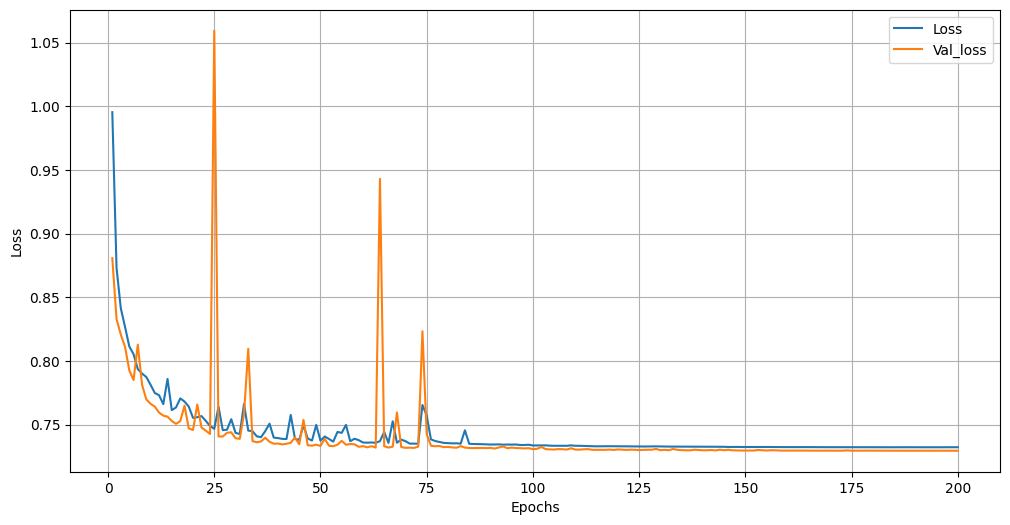

In [13]:
import matplotlib.pyplot as plt

# Callbacks
loss_EE = history_EE.history['loss']
val_EE = history_EE.history['val_loss']
epoch_EE = range(1, len(loss_EE) + 1)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(epoch_EE, loss_EE, label = 'Loss')
plt.plot(epoch_EE, val_EE, label = 'Val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.grid(True)
plt.legend()
plt.show()

W0000 00:00:1765772223.870861 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.871547 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.871987 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.872601 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.873022 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.873429 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.873840 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.874244 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772223.874668 1129260 gp

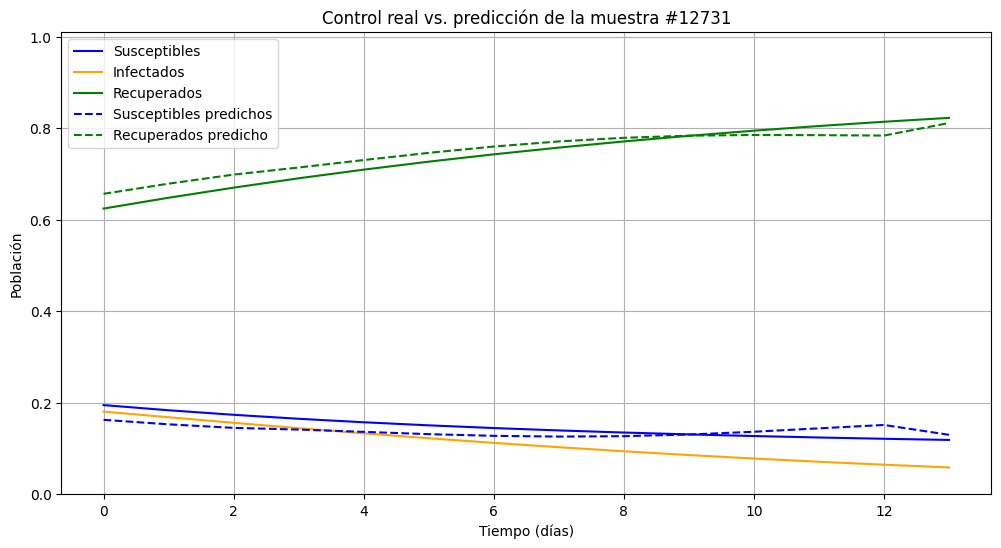

In [14]:
import random

# Muestra aleatoria
k = random.randint(0, len(X_test_EE))

# Entradas
tiempo_1 = np.arange(0, 14, 1)
infectados = X_test_EE[k]

# Salidas
tiempo_2 = np.arange(14, 28, 1)
susceptibles_salida = y_test_EE[k][:,0]
recuperados_salida = y_test_EE[k][:,1]

# Predicción
I = np.expand_dims(infectados, axis=0)
pred = model_EE.predict(I, verbose=0)

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(tiempo_1, susceptibles_salida, color='blue', label='Susceptibles')
plt.plot(tiempo_1, infectados, color='orange', label='Infectados')
plt.plot(tiempo_1, recuperados_salida, color='green', label='Recuperados')
plt.plot(tiempo_1, pred[0].flatten(), color='blue', linestyle='--', label='Susceptibles predichos')
plt.plot(tiempo_1, pred[1].flatten(), color='green', linestyle='--', label='Recuperados predicho')
plt.title(f'Control real vs. predicción de la muestra #{k}')
plt.xlabel('Tiempo (días)')
plt.ylabel('Población')
plt.ylim(0, 1.01)
plt.grid(True)
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import r2_score as r2m, mean_absolute_error

S_pred, R_pred, _ = model_EE.predict(X_test_EE, verbose=0)

S_real = y_test_EE[..., :1]
R_real = y_test_EE[..., 1:]

print("--- Métricas del Estimador de Estado (model_EE) ---")
print("R² global (S):", r2m(S_real.ravel(), S_pred.ravel()))
print("R² global (R):", r2m(R_real.ravel(), R_pred.ravel()))
print()
print("MAE (S):", mean_absolute_error(S_real.ravel(), S_pred.ravel()))
print("MAE (R):", mean_absolute_error(R_real.ravel(), R_pred.ravel()))

--- Métricas del Estimador de Estado (model_EE) ---
R² global (S): 0.9779784679412842
R² global (R): 0.9773622155189514

MAE (S): 0.030241360887885094
MAE (R): 0.030241360887885094


### Red Neuronal 2 (Predicción de Control)

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Input, LayerNormalization, Dropout, TimeDistributed

# Entrada
INPUT_SHAPE = (14, 3)
input_layer = Input(INPUT_SHAPE, name='Input_layer')

# Conv1D
x = Conv1D(128, 3, activation='relu', padding='causal', name='Conv1D_1')(input_layer)
x = LayerNormalization(name='LN_1')(x)
x = Dropout(0.3, name='DO_1')(x)

x = LSTM(128, dropout=0.3, return_sequences=True, name='LSTM_4')(x)
x = LayerNormalization(name='LayerNormalization_4')(x)

x = LSTM(64, dropout=0.3, return_sequences=True, name='LSTM_1')(x)
x = LayerNormalization(name='LayerNormalization_1')(x)

# Capa de procesamiento "ideal"
x = TimeDistributed(Dense(64, activation='relu'), name='TD_Proc')(x)
x = Dropout(0.2)(x)

# Salida
I_out = Dense(1, activation='sigmoid', name='I_out')(x)
u_out = Dense(1, activation='sigmoid', name='u_out')(x)

# Modelo
model_PC = Model(input_layer, [I_out, u_out])  

model_PC.compile(
    optimizer=Adam(1e-3),
    loss=[['mse'], ['mse']],                           
    metrics=[['mae'], ['mae']]          
)

model_PC.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_layer         │ (None, 14, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_1 (Conv1D)   │ (None, 14, 128)   │      1,280 │ Input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LN_1                │ (None, 14, 128)   │        256 │ Conv1D_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DO_1 (Dropout)      │ (None, 14, 128)   │          0 │ LN_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_4 (LSTM)       │ (None, 14, 128)   │    131,584 │ DO_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LayerNormalization… │ (None, 14, 128)   │        256 │ LSTM_4[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_1 (LSTM)       │ (None, 14, 64)    │     49,408 │ LayerNormalizati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LayerNormalization… │ (None, 14, 64)    │        128 │ LSTM_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TD_Proc             │ (None, 14, 64)    │      4,160 │ LayerNormalizati… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 64)    │          0 │ TD_Proc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ I_out (Dense)       │ (None, 14, 1)     │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ u_out (Dense)       │ (None, 14, 1)     │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 187,202 (731.26 KB)

 Trainable params: 187,202 (731.26 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Callbacks
earlystopping = EarlyStopping(
    monitor='val_loss',
    patience=10,          
    min_delta=5e-7,      
    mode='min',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=8,   
    factor=0.5,
    min_lr=1e-7,   
    cooldown=0,
    mode='min',
    verbose=1
)

# Train test split
X_tr_PC, X_val_PC, y_tr_PC, y_val_PC = train_test_split(
    X_train_PC[..., 1:2], y_train_PC,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=data_train['Altura_pico'].values
)

# Tensores individuales de y
y_tr_I = y_tr_PC[..., :1]
y_tr_u = y_tr_PC[..., 1:]

y_val_I = y_val_PC[..., :1]
y_val_u = y_val_PC[..., 1:]

y_train_dict = {'I_out': y_tr_I, 'u_out': y_tr_u}
y_val_dict   = {'I_out': y_val_I, 'u_out': y_val_u}

# Entrada X
X_pred_tr_EE = model_EE.predict(X_tr_PC)
X_pred_val_EE = model_EE.predict(X_val_PC)

in_X_tr = np.concatenate([X_pred_tr_EE[0], X_tr_PC, X_pred_tr_EE[1]], axis=-1)
in_X_val = np.concatenate([X_pred_val_EE[0], X_val_PC, X_pred_val_EE[1]], axis=-1)

history_PC = model_PC.fit(
    in_X_tr, y_train_dict,
    validation_data=(in_X_val, y_val_dict),
    epochs=400,
    batch_size=512,
    callbacks=[earlystopping, reduce_lr],
    shuffle=True,
    verbose=1
)

3250/3250 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Epoch 1/400
  1/204 ━━━━━━━━━━━━━━━━━━━━ 13:12 4s/step - I_out_loss: 0.2811 - I_out_mae: 0.5060 - loss: 0.4115 - u_out_loss: 0.1303 - u_out_mae: 0.2928

W0000 00:00:1765772244.238742 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.239669 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.240117 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.240504 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.241005 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.241447 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.241865 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.242239 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772244.242596 1129261 gp

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - I_out_loss: 0.0153 - I_out_mae: 0.0667 - loss: 0.0392 - u_out_loss: 0.0240 - u_out_mae: 0.1118

W0000 00:00:1765772246.766247 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.766722 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.767018 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.767261 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.767534 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.767847 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.768117 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.768355 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772246.768587 1129260 gp

204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - I_out_loss: 0.0047 - I_out_mae: 0.0404 - loss: 0.0178 - u_out_loss: 0.0130 - u_out_mae: 0.0818 - val_I_out_loss: 6.9556e-04 - val_I_out_mae: 0.0181 - val_loss: 0.0048 - val_u_out_loss: 0.0041 - val_u_out_mae: 0.0433 - learning_rate: 0.0010
Epoch 2/400


W0000 00:00:1765772247.756072 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.756483 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.756777 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.757051 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.757320 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.757595 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.757858 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.758123 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772247.758389 1129261 gp

204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - I_out_loss: 0.0013 - I_out_mae: 0.0258 - loss: 0.0064 - u_out_loss: 0.0050 - u_out_mae: 0.0517 - val_I_out_loss: 4.8000e-04 - val_I_out_mae: 0.0153 - val_loss: 0.0031 - val_u_out_loss: 0.0026 - val_u_out_mae: 0.0349 - learning_rate: 0.0010
Epoch 3/400
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - I_out_loss: 0.0011 - I_out_mae: 0.0233 - loss: 0.0048 - u_out_loss: 0.0037 - u_out_mae: 0.0442 - val_I_out_loss: 3.3207e-04 - val_I_out_mae: 0.0122 - val_loss: 0.0020 - val_u_out_loss: 0.0017 - val_u_out_mae: 0.0265 - learning_rate: 0.0010
Epoch 4/400
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - I_out_loss: 9.3830e-04 - I_out_mae: 0.0217 - loss: 0.0038 - u_out_loss: 0.0029 - u_out_mae: 0.0390 - val_I_out_loss: 2.7658e-04 - val_I_out_mae: 0.0109 - val_loss: 0.0016 - val_u_out_loss: 0.0014 - val_u_out_mae: 0.0235 - learning_rate: 0.0010
Epoch 5/400
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - I_out_loss: 8.4104e-04 - I_out_mae: 0.0206 - loss: 0.0032 - u_ou

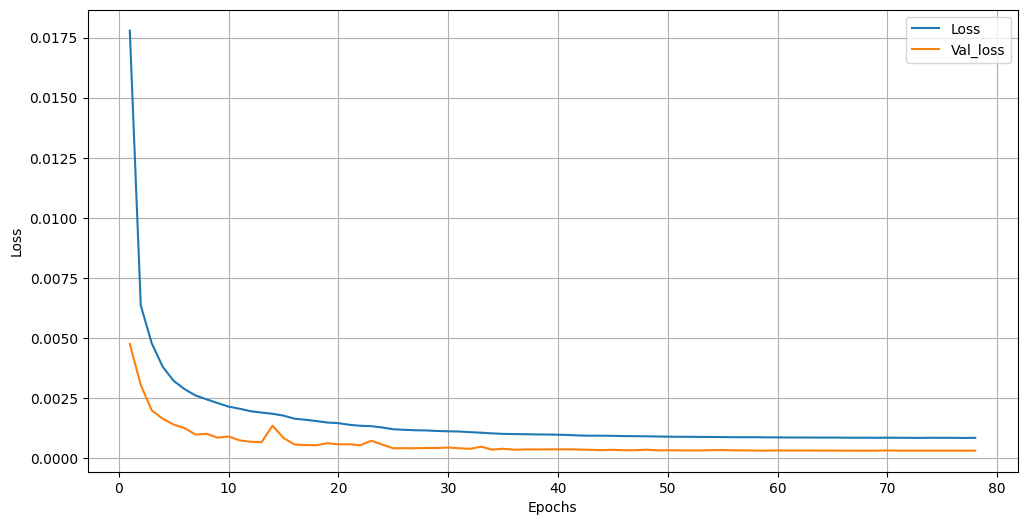

In [18]:
# Callbacks
loss_PC = history_PC.history['loss']
val_PC = history_PC.history['val_loss']
epoch_PC = range(1, len(loss_PC) + 1)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(epoch_PC, loss_PC, label = 'Loss')
plt.plot(epoch_PC, val_PC, label = 'Val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.grid(True)
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


W0000 00:00:1765772616.553219 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.554224 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.554643 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.555057 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.555360 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.555642 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.555969 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.556296 1129260 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772616.556755 1129260 gp

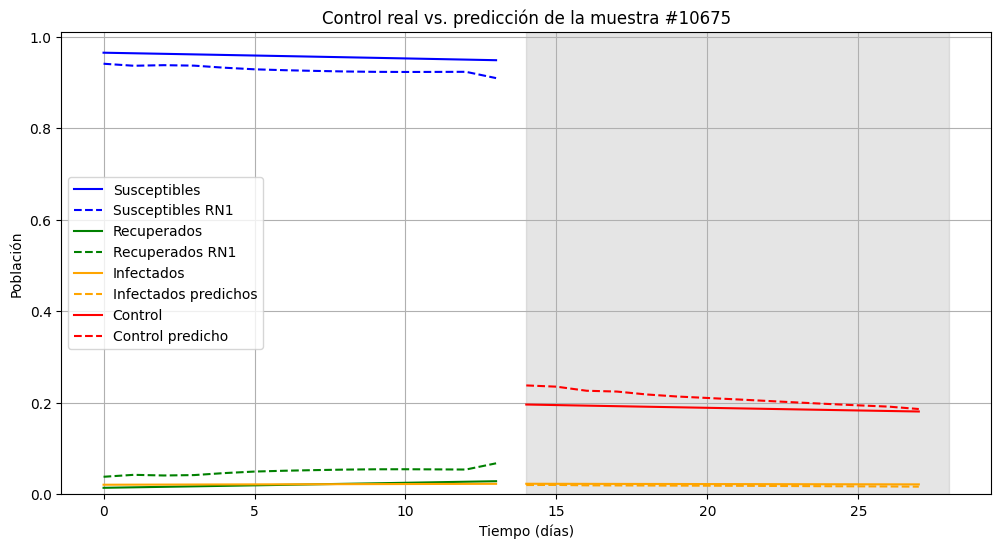

In [19]:
import random

# Muestra aleatoria
k = random.randint(0, len(X_test_PC))

# Entradas
tiempo_1 = np.arange(0, 14, 1)
sus_inp = X_test_PC[..., :1][k]
infectados = X_test_PC[..., 1:2][k]
rec_inp = X_test_PC[..., 2:][k]


# Entrada Red Neuronal 1
inf = np.expand_dims((infectados), axis=0)
suseptibles, recuperados, _ = model_EE.predict(inf)
Input = np.concatenate([suseptibles, inf, recuperados], axis=2)

# Salidas
tiempo_2 = np.arange(14, 28, 1)
infectados_salida = y_test_PC[k][:,0]
control_salida = y_test_PC[k][:,1]

# Predicción
dI__du_pred = model_PC.predict(Input, verbose=0)

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(tiempo_1, sus_inp, color='blue', label='Susceptibles')
plt.plot(tiempo_1, suseptibles.flatten(), color='blue', linestyle='--', label='Susceptibles RN1')
plt.plot(tiempo_1, rec_inp, color='green', label='Recuperados')
plt.plot(tiempo_1, recuperados.flatten(), color='green', linestyle='--', label='Recuperados RN1')
plt.plot(tiempo_1, infectados, color='orange', label='Infectados')
plt.plot(tiempo_2, dI__du_pred[0].flatten(), color='orange', linestyle='--', label='Infectados predichos')
plt.plot(tiempo_2, infectados_salida, color='orange')
plt.plot(tiempo_2, control_salida, color='red', label='Control')
plt.plot(tiempo_2, dI__du_pred[1].flatten(), color='red', linestyle='--', label='Control predicho')
plt.axvspan(14, 28, color='gray', alpha=0.2)
#plt.axhspan(0.9, 1.0, alpha=0.2, color = 'red', label='confinamiento extremo')
#plt.axhspan(0.7, 0.9, alpha=0.2, color = 'tomato', label='medidas muy estrictas')    
#plt.axhspan(0.5, 0.7, alpha=0.2, color = 'orange', label='medidas fuertes')
#plt.axhspan(0.3, 0.5, alpha=0.2, color = 'gold', label='medidas moderadas')
#plt.axhspan(0.1, 0.3, alpha=0.2, color = 'yellow', label='medidas leves')
#plt.axhspan(0, 0.1, alpha=0.2, color = 'green', label='casi sin medidas')    
plt.title(f'Control real vs. predicción de la muestra #{k}')
plt.ylim(0, 1.01)
plt.xlabel('Tiempo (días)')
plt.ylabel('Población')
plt.grid(True)
plt.legend()
plt.show()

In [20]:
X_test_PC[..., 1:2].shape

(26000, 14, 1)

In [21]:
import numpy as np
from sklearn.metrics import r2_score as r2m, mean_absolute_error

S_pred_PC, R_pred_PC, __ = model_EE.predict(X_test_PC[..., 1:2], verbose=0)
Inp_PC = np.concatenate([S_pred_PC, X_test_PC[..., 1:2], R_pred_PC], axis=2)
I_predicha, u_predicha = model_PC.predict(Inp_PC, verbose=0)


# 4. Ahora tu código de métricas funcionará
I_real = y_test_PC[..., :1]
u_real = y_test_PC[..., 1:]

print("--- Métricas del Predicción de Control (model_PC) ---")
print("R² global (I):", r2m(I_real.ravel(), I_predicha.ravel()))
print("R² global (u):", r2m(u_real.ravel(), u_predicha.ravel()))
print()
print("MAE (S):", mean_absolute_error(I_real.ravel(), I_predicha.ravel()))
print("MAE (R):", mean_absolute_error(u_real.ravel(), u_predicha.ravel()))

W0000 00:00:1765772619.755082 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.755825 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.756243 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.756533 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.756839 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.757134 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.757408 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.757689 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772619.757970 1129261 gp

--- Métricas del Predicción de Control (model_PC) ---
R² global (I): 0.9761893153190613
R² global (u): 0.9950788021087646

MAE (S): 0.004863463807851076
MAE (R): 0.008719759061932564


# Predicción real

In [22]:
data_covid = pd.read_csv('OxCGRT_compact_national_v1.csv')
data_covid = data_covid[['CountryName', 'RegionName', 'Jurisdiction', 'Date', 'ConfirmedCases', 'ContainmentHealthIndex_Average']]
data_covid['CountryName'].unique()

array(['Aruba', 'Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Australia', 'Austria',
       'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso',
       'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas',
       'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bermuda',
       'Bolivia', 'Brazil', 'Barbados', 'Brunei', 'Bhutan', 'Botswana',
       'Central African Republic', 'Canada', 'Switzerland', 'Chile',
       'China', "Cote d'Ivoire", 'Cameroon',
       'Democratic Republic of Congo', 'Congo', 'Colombia', 'Cape Verde',
       'Costa Rica', 'Cuba', 'Cyprus', 'Czech Republic', 'Germany',
       'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria',
       'Ecuador', 'Egypt', 'Eritrea', 'Spain', 'Estonia', 'Ethiopia',
       'Finland', 'Fiji', 'France', 'Faeroe Islands', 'Gabon',
       'United Kingdom', 'Georgia', 'Ghana', 'Guinea', 'Gambia', 'Greece',
       'Greenland', 'Guatemala', 'Guam', 'Guyana', 'Hong Kong',
      

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


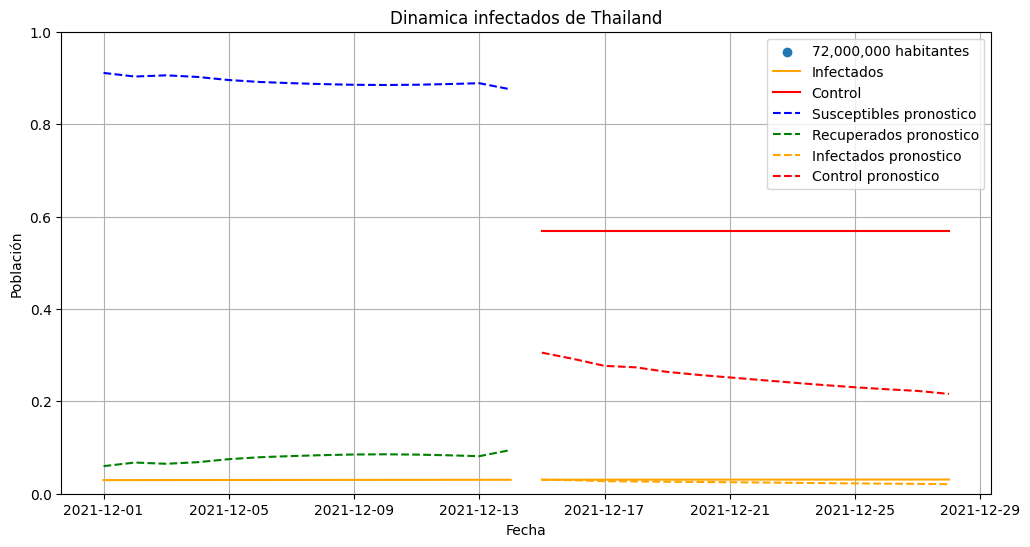

In [49]:
def normalizacion(data, habitantes):
    scaled_data = []
    for i in data:
        i_rel = i / int(habitantes)
        scaled_data.append(i_rel)
    return scaled_data

# Pais
pais = 'Thailand'
habitantes = 72_000_000
fecha_inicio = 700

# Entradas
df_pais = data_covid[data_covid['CountryName']==pais].copy()
df_pais['Date'] = pd.to_datetime(df_pais['Date'], format="%Y%m%d", errors='coerce')
tiempo_1 = pd.to_datetime(df_pais['Date'], format="%Y%m%d")[fecha_inicio:fecha_inicio+14]

infectados_1 = np.array(normalizacion(df_pais['ConfirmedCases'], habitantes)[fecha_inicio:fecha_inicio+14], dtype=np.float32) # Principal
inf = np.expand_dims(np.expand_dims(infectados_1, 0), -1)
S, R, __ = model_EE.predict(inf)
Inp_R = np.concatenate([S, inf, R], axis=2)
I_oout, u_oout = model_PC.predict(Inp_R)

#Salidas
tiempo_2 = pd.to_datetime(df_pais['Date'], format="%Y%m%d")[fecha_inicio+14:fecha_inicio+28]
infectados_2 = normalizacion(df_pais['ConfirmedCases'], habitantes)[fecha_inicio+14:fecha_inicio+28]
control_2 = normalizacion(df_pais['ContainmentHealthIndex_Average'], 100)[fecha_inicio+14:fecha_inicio+28]

# Pronostico   
plt.figure(figsize=(12,6))
plt.title(f'Dinamica infectados de {pais}')

plt.scatter([],[], label=f'{habitantes:,} habitantes')
plt.plot(tiempo_1, infectados_1, color='orange', label='Infectados')
plt.plot(tiempo_2, infectados_2, color='orange')
plt.plot(tiempo_2, control_2, color='red', label='Control')
plt.plot(tiempo_1, S.flatten(), color='blue', linestyle='--', label='Susceptibles pronostico')
plt.plot(tiempo_1, R.flatten(), color='green', linestyle='--', label='Recuperados pronostico')
plt.plot(tiempo_2, I_oout.flatten(), color='orange', linestyle='--', label='Infectados pronostico')
plt.plot(tiempo_2, u_oout.flatten(), color='red', linestyle='--', label='Control pronostico')
plt.ylabel('Población')
plt.xlabel('Fecha')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


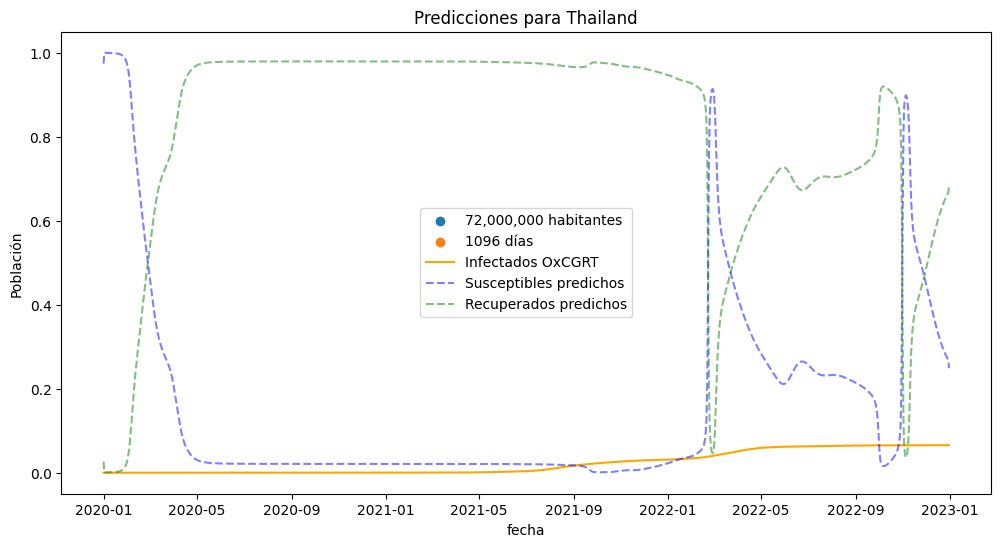

In [50]:
# Dinamica de infectados
infectados_1_GL = np.array(normalizacion(df_pais['ConfirmedCases'], habitantes), dtype=np.float32) 
inf_GL = np.expand_dims(np.expand_dims(infectados_1_GL, 0), -1)

# Prediccion de S y R
S_GL, R_GL, __GL = model_EE.predict(inf_GL)
Inp_R_GL = np.concatenate([S_GL, inf_GL, R_GL], axis=2)

# Gráfica
tiempo_gral = pd.to_datetime(df_pais['Date'], format="%Y%m%d")

plt.figure(figsize=(12,6))
plt.title(f'Predicciones para {pais}')
plt.scatter([],[], label=f'{habitantes:,} habitantes')
plt.scatter([],[], label=f'{len(tiempo_gral)} días')
plt.plot(tiempo_gral, infectados_1_GL, color='orange', label='Infectados OxCGRT')
plt.plot(tiempo_gral, S_GL.flatten(), color='blue', linestyle='--', alpha=0.5, label='Susceptibles predichos')
plt.plot(tiempo_gral, R_GL.flatten(), color='green', linestyle='--', alpha=0.5, label='Recuperados predichos')
plt.xlabel('fecha')
plt.ylabel('Población')
plt.legend()
plt.show()

--- Métricas para Thailand ---
R² (Infectados): 0.8720601797103882
MAE (Infectados): 0.0066126128658652306
R² (Control): -4.666114773627561
MAE (Control): 0.34024861947110896


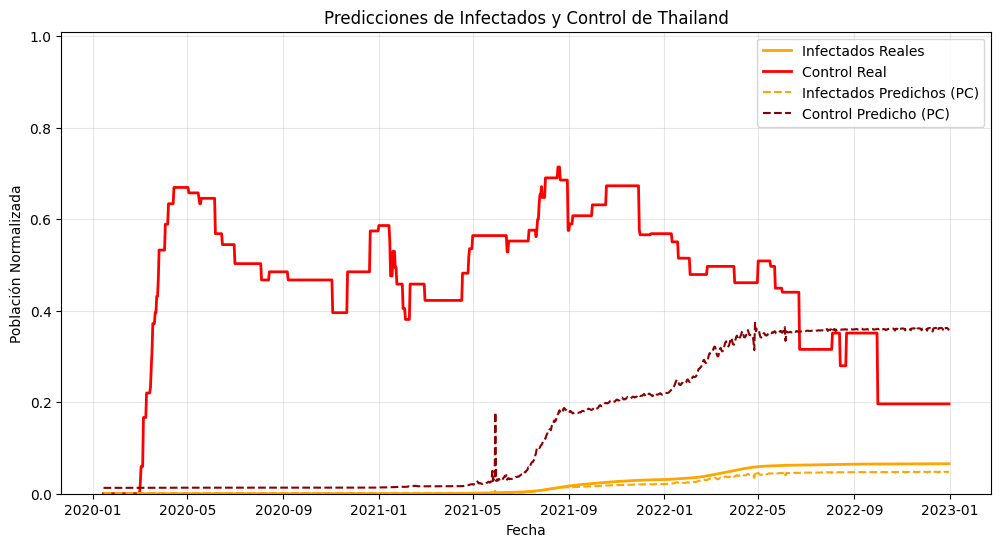

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error


infectados_total = np.array(normalizacion(df_pais['ConfirmedCases'], habitantes), dtype=np.float32)

# Generación de ventana
window_size = 14
I_test = []

for i in range(len(infectados_total) - window_size):
    I_test.append(infectados_total[i : i + window_size])

# Red neuronal 1
I_test = np.array(I_test) 
I_test = np.expand_dims(I_test, -1) 

S_pred, R_pred, _ = model_EE.predict(I_test, verbose=0)

# Red neuronal 2
input_PC = np.concatenate([S_pred, I_test, R_pred], axis=2)
I_out_pred, u_out_pred = model_PC.predict(input_PC, verbose=0)

# 4. Extracción de la predicción de interés
# model_PC devuelve secuencias (Batch, 14, 1). 
# Nos interesa el ÚLTIMO valor de cada ventana (el pronóstico para el día siguiente o actual)
I_final_series = I_out_pred[:, -1, 0] 
u_final_series = u_out_pred[:, -1, 0]

# S y R también (opcional para graficar)
S_final_series = S_pred[:, -1, 0]
R_final_series = R_pred[:, -1, 0]

# 5. Alineación de Ground Truth (Datos Reales)
# Como usamos una ventana de 14 para predecir, nuestras predicciones empiezan en el día 14
ground_truth_I = infectados_total[window_size:]
ground_truth_u = np.array(normalizacion(df_pais['ContainmentHealthIndex_Average'], 100))[window_size:]
fechas_recortadas = pd.to_datetime(df_pais['Date'], format="%Y%m%d")[window_size:]

# 6. Métricas y Gráficas
print(f"--- Métricas para {pais} ---")
print("R² (Infectados):", r2_score(ground_truth_I, I_final_series))
print("MAE (Infectados):", mean_absolute_error(ground_truth_I, I_final_series))
print("R² (Control):", r2_score(ground_truth_u, u_final_series))
print("MAE (Control):", mean_absolute_error(ground_truth_u, u_final_series))

plt.figure(figsize=(12,6))
plt.title(f'Predicciones de Infectados y Control de {pais}')

# Datos Reales
plt.plot(fechas_recortadas, ground_truth_I, color='orange', label='Infectados Reales', linewidth=2)
plt.plot(fechas_recortadas, ground_truth_u, color='red', label='Control Real', linewidth=2)

# Predicciones
plt.plot(fechas_recortadas, I_final_series, color='orange', linestyle='--', label='Infectados Predichos (PC)')
plt.plot(fechas_recortadas, u_final_series, color='darkred', linestyle='--', label='Control Predicho (PC)')

plt.ylabel('Población Normalizada')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.01)
plt.show()

In [26]:
I_test[:, -1, 0].shape

(1082,)

In [27]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

I = np.array(normalizacion(df_pais['ConfirmedCases'], habitantes), dtype=np.float32)
u = np.array(normalizacion(df_pais['ContainmentHealthIndex_Average'], 100), dtype=np.float32)

T = len(I)
win = 14

I_pred = np.full(T, np.nan, dtype=np.float32)
u_pred = np.full(T, np.nan, dtype=np.float32)

for t in range(0, T - 2*win + 1):
    I_in = I[t:t+win][None, :, None]                 # (1,14,1)

    # EE: misma ventana t..t+13
    S_hat, R_hat, _ = model_EE.predict(I_in, verbose=0)

    # PC: usa esa misma ventana para predecir t+14..t+27
    X = np.concatenate([S_hat, I_in, R_hat], axis=2)  # (1,14,3)
    I_out, u_out = model_PC.predict(X, verbose=0)     # (1,14,1), (1,14,1)

    I_pred[t+win:t+2*win] = I_out[0, :, 0]
    u_pred[t+win:t+2*win] = u_out[0, :, 0]

maskI = ~np.isnan(I_pred)
maskU = ~np.isnan(u_pred)

print("R² (I):", r2_score(I[maskI], I_pred[maskI]))
print("MAE (I):", mean_absolute_error(I[maskI], I_pred[maskI]))
print("R² (u):", r2_score(u[maskU], u_pred[maskU]))
print("MAE (u):", mean_absolute_error(u[maskU], u_pred[maskU]))

R² (I): 0.8134115934371948
MAE (I): 0.029912352561950684
R² (u): -3.0672779083251953
MAE (u): 0.20851992070674896


In [28]:
import numpy as np
from sklearn.metrics import r2_score as r2m, mean_absolute_error

infectados_1_GL = np.array(normalizacion(df_pais['ConfirmedCases'], habitantes), dtype=np.float32) # Principal
inf_GL = np.expand_dims(np.expand_dims(infectados_1_GL, 0), -1)
S_GL, R_GL, __GL = model_EE.predict(inf_GL)
Inp_R_GL = np.concatenate([S_GL, inf_GL, R_GL], axis=2)
I_oout_GL, u_oout_GL = model_PC.predict(Inp_R_GL)

infectados_2_GL = np.array(normalizacion(df_pais['ConfirmedCases'], habitantes))
control_2_GL = np.array(normalizacion(df_pais['ContainmentHealthIndex_Average'], 100))

print("--- Métricas del Predicción de Control (model_PC) ---")
print("R² global (I):", r2m(infectados_2_GL.ravel(), I_oout_GL.ravel()))
print("R² global (u):", r2m(control_2_GL.ravel(), u_oout_GL.ravel()))
print()
print("MAE (S):", mean_absolute_error(infectados_2_GL.ravel(), I_oout_GL.ravel()))
print("MAE (R):", mean_absolute_error(control_2_GL.ravel(), u_oout_GL.ravel()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


W0000 00:00:1765772848.223514 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.224365 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.224766 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.225109 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.225478 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.225814 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.226138 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.226484 1129261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1765772848.226827 1129261 gp

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
--- Métricas del Predicción de Control (model_PC) ---
R² global (I): 0.06574300583009463
R² global (u): -10.749675541697616

MAE (S): 0.08469362083873713
MAE (R): 0.4541857775834487


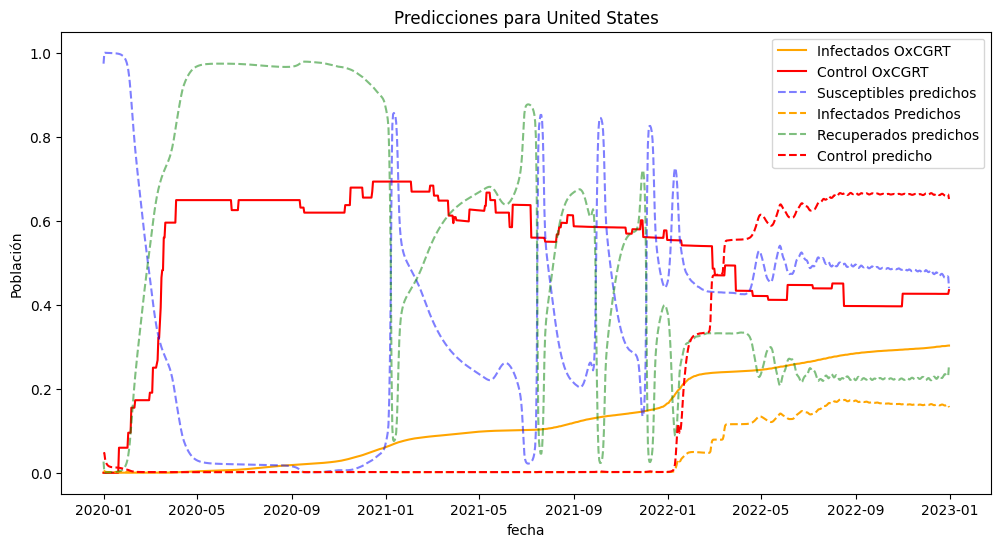

In [29]:
plt.figure(figsize=(12,6))
plt.title(f'Predicciones para {pais}')
plt.plot(pd.to_datetime(df_pais['Date'], format="%Y%m%d"), infectados_1_GL, color='orange', label='Infectados OxCGRT')
plt.plot(pd.to_datetime(df_pais['Date'], format="%Y%m%d"), control_2_GL, color='red', label='Control OxCGRT')
plt.plot(pd.to_datetime(df_pais['Date'], format="%Y%m%d"), S_GL.flatten(), color='blue', linestyle='--', alpha=0.5, label='Susceptibles predichos')
plt.plot(pd.to_datetime(df_pais['Date'], format="%Y%m%d"), I_oout_GL.flatten(), color='orange', linestyle='--', alpha=1, label='Infectados Predichos')
plt.plot(pd.to_datetime(df_pais['Date'], format="%Y%m%d"), R_GL.flatten(), color='green', linestyle='--', alpha=0.5, label='Recuperados predichos')
plt.plot(pd.to_datetime(df_pais['Date'], format="%Y%m%d"), u_oout_GL.flatten(), color='red', linestyle='--', label='Control predicho')
plt.xlabel('fecha')
plt.ylabel('Población')
plt.legend()
plt.show()